In [1]:
from google.colab import files
uploaded = files.upload()

Saving sample_submission.csv to sample_submission (6).csv
Saving test.csv to test (6).csv
Saving train.csv to train (6).csv


In [2]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (36696, 7)
Test shape: (3, 5)
Sample submission shape: (3, 2)


The datasets were loaded successfully. The training dataset has 36,696 rows and 7 columns, which will be used for EDA, preprocessing, and model training. The test set is much smaller, with 3 rows and 5 columns, it does not include labels, this will be used towards the end for final predictions. The sample submission file has 3 rows and 2 columns and provides the format required for submitting predictions. So far, all three datasets are ready for analysis.

In [3]:
train.info()
test.info()

print("Train columns:", train.columns)
print("Test columns:", test.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36696 entries, 0 to 36695
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              36696 non-null  int64 
 1   QuestionId          36696 non-null  int64 
 2   QuestionText        36696 non-null  object
 3   MC_Answer           36696 non-null  object
 4   StudentExplanation  36696 non-null  object
 5   Category            36696 non-null  object
 6   Misconception       9860 non-null   object
dtypes: int64(2), object(5)
memory usage: 2.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              3 non-null      int64 
 1   QuestionId          3 non-null      int64 
 2   QuestionText        3 non-null      object
 3   MC_Answer           3 non-null      object
 4   StudentExplanatio

The training dataset includes student responses, question metadata, and the target column misconception, which has 9,860 non-null entries. This means that only a subset of the training examples are labeled with a misconception. The test dataset does not include the category or misconception columns, which means that it is only for prediction. Essentially, the train and test datasets have the same core features (row_id, QuestionId, QuestionText, MC_Answer, and StudentExplanation), maintaining consistency between training and inference.

In [4]:
# Check missing values
print("Missing values:\n", train.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", train.duplicated().sum())

# Count unique values per column
print("\nUnique values per column:\n", train.nunique())

Missing values:
 row_id                    0
QuestionId                0
QuestionText              0
MC_Answer                 0
StudentExplanation        0
Category                  0
Misconception         26836
dtype: int64

Duplicate rows: 0

Unique values per column:
 row_id                36696
QuestionId               15
QuestionText             15
MC_Answer                49
StudentExplanation    35726
Category                  6
Misconception            35
dtype: int64


The training data shows no missing values in most columns, but the target column Misconception has 26,836 missing entries, which means only about 10,000 responses are labeled for supervised learning. There are no duplicate rows, which confirms data integrity. After looking at unique values, we see that there are 15 unique questions, 49 distinct multiple-choice answers, and 35 different misconceptions. The StudentExplanation column has over 35,000 unique entries, showing that most student responses are distinct. Overall, the dataset is clean and ready for EDA and preprocessing.

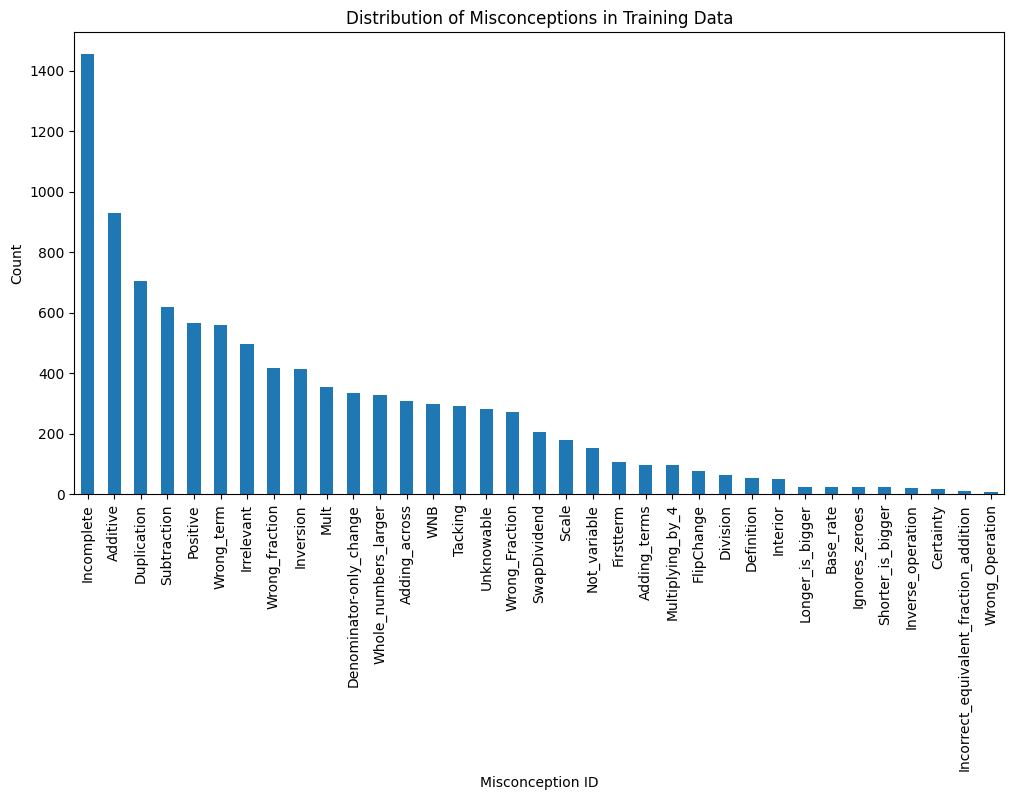

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
train['Misconception'].value_counts().plot(kind='bar')
plt.title("Distribution of Misconceptions in Training Data")
plt.xlabel("Misconception ID")
plt.ylabel("Count")
plt.show()

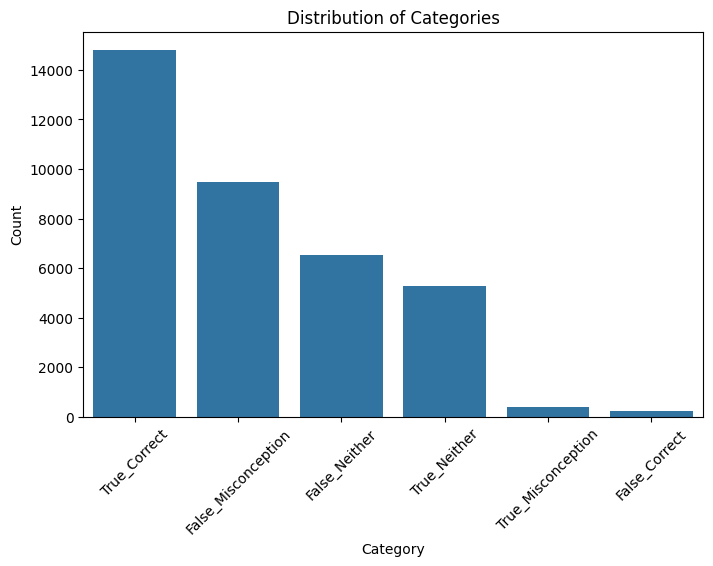

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='Category', order=train['Category'].value_counts().index)
plt.title("Distribution of Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

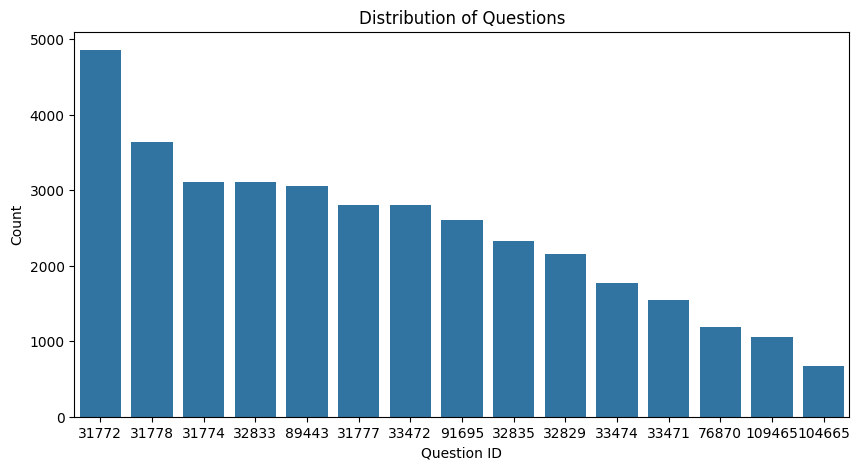

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=train, x='QuestionId', order=train['QuestionId'].value_counts().index)
plt.title("Distribution of Questions")
plt.xlabel("Question ID")
plt.ylabel("Count")
plt.show()

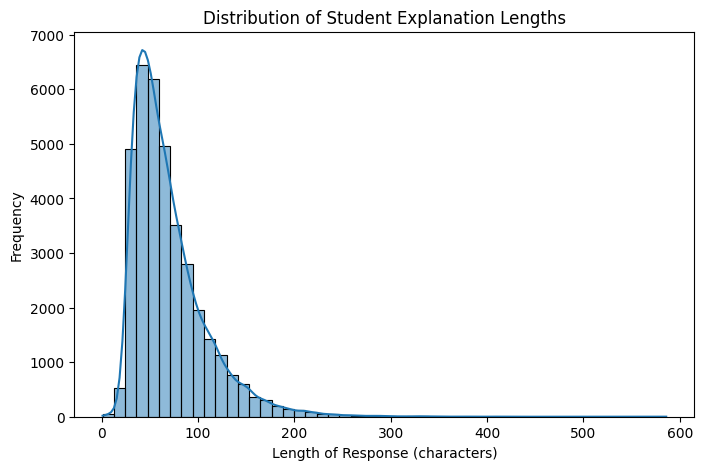

In [8]:
train['explanation_length'] = train['StudentExplanation'].str.len()

plt.figure(figsize=(8,5))
sns.histplot(train['explanation_length'], bins=50, kde=True)
plt.title("Distribution of Student Explanation Lengths")
plt.xlabel("Length of Response (characters)")
plt.ylabel("Frequency")
plt.show()

In [9]:
# Misconception stats
miscon_stats = train['Misconception'].value_counts()
most_common_miscon = miscon_stats.idxmax()
least_common_miscon = miscon_stats.idxmin()
miscon_skew = miscon_stats.describe()

# Category stats
cat_stats = train['Category'].value_counts()
most_common_cat = cat_stats.idxmax()
least_common_cat = cat_stats.idxmin()

# Question stats
q_stats = train['QuestionId'].value_counts()
most_common_q = q_stats.idxmax()
least_common_q = q_stats.idxmin()

# Explanation length stats
expl_stats = train['explanation_length'].describe()

# Create summary table
summary_table = pd.DataFrame({
    'Feature': ['Misconception', 'Category', 'QuestionId', 'Explanation Length'],
    'Most Common / Avg': [most_common_miscon, most_common_cat, most_common_q, round(expl_stats['mean'],1)],
    'Least Common / Range': [least_common_miscon, least_common_cat, least_common_q, f"{int(expl_stats['min'])}-{int(expl_stats['max'])}"],
    'Additional Info': [f"Skew: {miscon_skew['max']/miscon_skew['mean']:.2f}",
                        f"Counts: {cat_stats.values}",
                        f"Counts: {q_stats.values}",
                        f"Median: {int(expl_stats['50%'])}, Std: {round(expl_stats['std'],1)}"]
})

summary_table

,Feature,Most Common / Avg,Least Common / Range,Additional Info
0,Misconception,Incomplete,Wrong_Operation,Skew: 5.16
1,Category,True_Correct,False_Correct,Counts: [14802 9457 6542 5265 403 227]
2,QuestionId,31772,104665,Counts: [4857 3640 3115 3105 3054 2809 2800 26...
3,Explanation Length,70.0,1-586,"Median: 60, Std: 38.7"


EDA reveals several key points to pay attention to in the training data.

The most common misconception is “Incomplete”, while “Wrong_Operation” is the least common, and the distribution is quite skewed (skew ratio ~5.16).

“True_Correct” is the most frequent and “False_Correct” the least category, with counts ranging widely across the six categories.

For individual questions, QuestionId 31772 appears frequently, whereas QuestionId 104665 is the least frequent.

Student explanations vary in length, with an average of about 70 characters, with a median of 60 and a standard deviation of 38.

Most responses are short to medium, with lengths ranging from 1 to 586 characters. These insights will help guide preprocessing and feature engineering in the next steps.

In [10]:
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Clean StudentExplanation text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

train['cleaned_explanation'] = train['StudentExplanation'].apply(clean_text)
test['cleaned_explanation'] = test['StudentExplanation'].apply(clean_text)

# 2. Encode Misconception labels (train only)
le = LabelEncoder()
train['misconception_label'] = le.fit_transform(train['Misconception'].fillna("Unknown"))

# 3. Train-validation split for internal testing
X = train['cleaned_explanation']
y = train['misconception_label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test['cleaned_explanation'])

print("Preprocessing complete. TF-IDF features ready for modeling.")

Preprocessing complete. TF-IDF features ready for modeling.


We cleaned the StudentExplanation text by converting to lowercase, removing numbers and punctuation, and stripping extra spaces.

We labeled missing Misconception labels as "Unknown" and all labels were encoded numerically for modeling. The training data was split into an 80/20 train-validation set with stratification to preserve label distribution.

Finally, TF-IDF vectorization was applied to both the explanations in train, validation, and test sets, generating features ready for input into machine learning models.

The preprocessing pipeline makes sure the datasets are consistent and clean.


Classification Report (TF-IDF + Oversampled Hybrid Ensemble):
                                        precision    recall  f1-score   support

                         Adding_across      0.481     0.820     0.606        61
                          Adding_terms      0.941     0.842     0.889        19
                              Additive      0.881     0.758     0.815       186
                             Base_rate      1.000     1.000     1.000         5
                             Certainty      1.000     1.000     1.000         3
                            Definition      0.889     0.727     0.800        11
               Denominator-only_change      0.737     0.836     0.783        67
                              Division      0.500     0.462     0.480        13
                           Duplication      0.808     0.894     0.848       141
                             Firstterm      0.556     0.476     0.513        21
                            FlipChange      0.263     0.

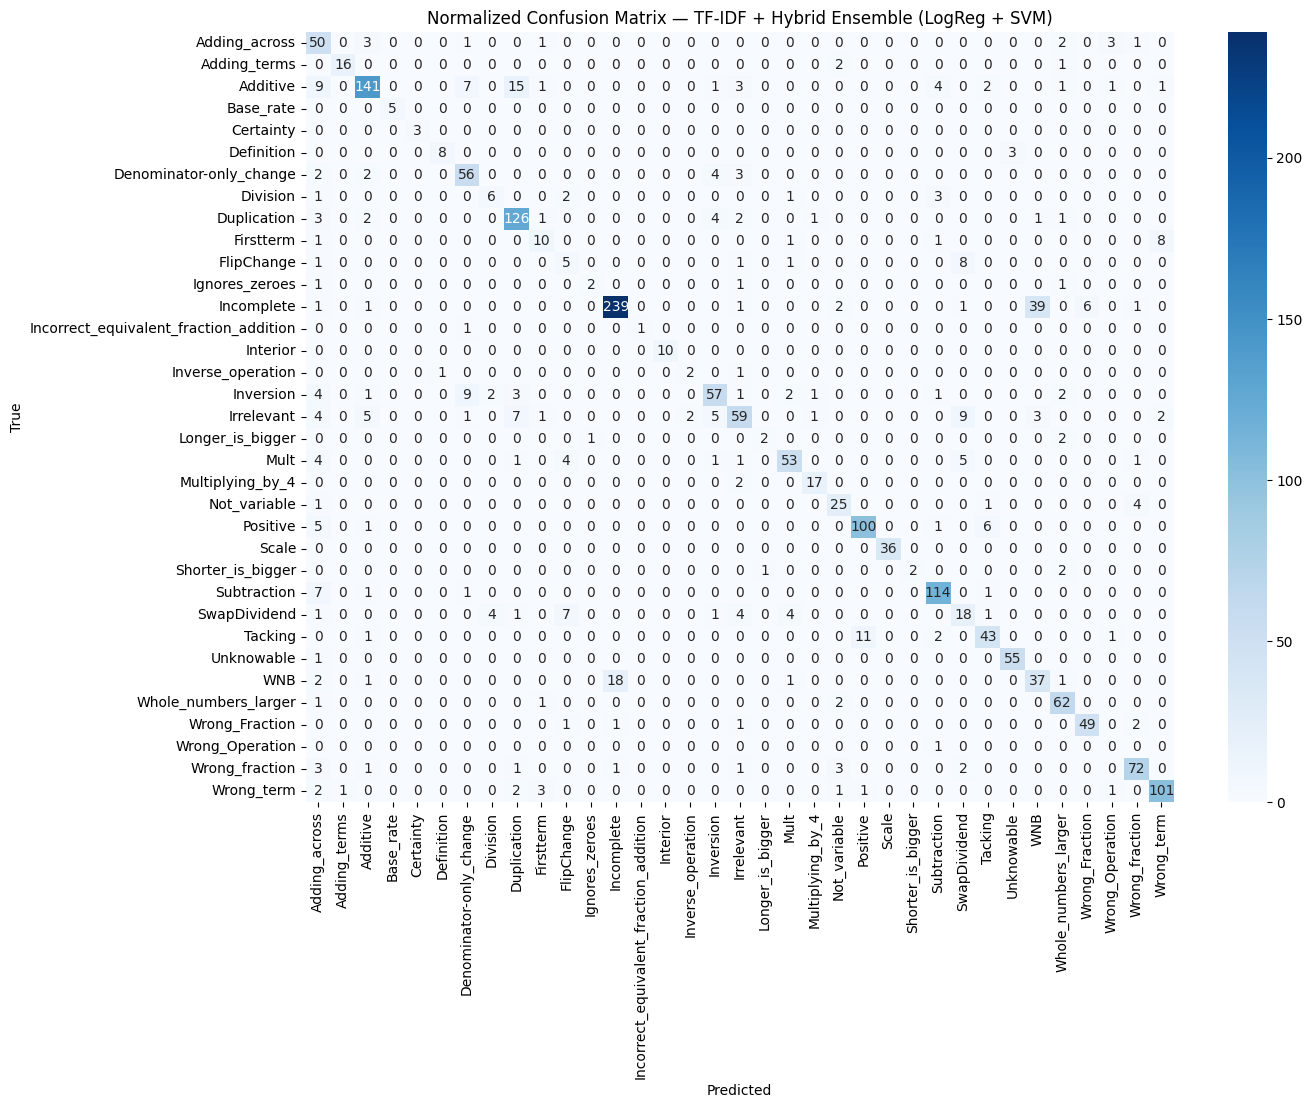

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [11]:
# Baseline Model

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from sklearn.calibration import CalibratedClassifierCV

# 1. Use only labeled data for supervised learning
df_labeled = train.dropna(subset=['Misconception'])
X = df_labeled['StudentExplanation']
y = df_labeled['Misconception']

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Shared TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000
)

# Transform text data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Oversample rare classes in training
ros = RandomOverSampler(random_state=42)
X_train_tfidf, y_train = ros.fit_resample(X_train_tfidf, y_train)

# 4. Define base classifiers
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=1000,
    C=1.0,
    n_jobs=-1,
    class_weight='balanced'
)

# Calibrate LinearSVC for probability output (for soft voting)
svm_clf = CalibratedClassifierCV(
    estimator=LinearSVC(class_weight='balanced'),
    cv=3
)

# 5. Ensemble (soft voting)
ensemble = VotingClassifier(
    estimators=[('lr', log_reg), ('svm', svm_clf)],
    voting='soft',
    n_jobs=-1
)

# 6. Fit model
ensemble.fit(X_train_tfidf, y_train)

# 7. Predict and evaluate
y_pred = ensemble.predict(X_test_tfidf)

print("\nClassification Report (TF-IDF + Oversampled Hybrid Ensemble):")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

# 8. Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=ensemble.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=ensemble.classes_,
            yticklabels=ensemble.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix — TF-IDF + Hybrid Ensemble (LogReg + SVM)")
plt.xticks(rotation=90)

# 9. Save to Downloads
downloads_path = r"C:\Users\unurg\Downloads"
os.makedirs(downloads_path, exist_ok=True)  # ensure folder exists
img_filename = os.path.join(downloads_path, "confusion_matrix_hybrid.png")

plt.savefig(img_filename, dpi=300, bbox_inches='tight')
plt.show()

print

We developed a hybrid ensemble baseline model combining Logistic Regression and a calibrated Linear SVM, trained on TF-IDF features extracted from student explanations. To address class imbalance, we applied RandomOverSampler to the training data. The model was evaluated on a stratified validation set using precision, recall, and F1-score metrics.

Key insights from the prediction results:

- Overall Performance:
The model achieved 80.2% accuracy and a weighted F1-score of 80.6%, demonstrating strong predictive capability across most misconception categories.

- Class Distribution:
Predictions were most accurate for frequent misconceptions such as Incomplete, Subtraction, and Wrong_term, each with F1-scores above 0.85. In contrast, rare classes like Wrong_Operation and Shorter_is_bigger exhibited low recall, underscoring the difficulty of modeling underrepresented misconceptions.

- Model Calibration:
Calibrating the SVM enabled soft voting within the ensemble, which improved confidence estimates and helped balance precision and recall across classes.

- Confusion Matrix Analysis:
The normalized confusion matrix revealed that most misclassifications occurred between conceptually similar misconceptions, suggesting that semantic overlap in student responses may be a key source of error.
